# 01 — Whole-slide exploration (interactive)
Inspect QC, FOV structure, expression clustering, and spatial/FOV association without committing parameters to production.

In [52]:
# ============================================================
# Dataset_02 CosMx — Jupyter initialization
# ============================================================

from pathlib import Path
import sys
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc


# ------------------------------------------------------------
# Robustly locate project root
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd().resolve()


def find_project_root(start: Path) -> Path:
    """
    Search current directory and its parents for the project root.

    A valid project root contains:
        src/
        data/
    """

    for candidate in [start, *start.parents]:

        if (
            (candidate / "src").is_dir()
            and
            (candidate / "data").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Could not locate project root.\n"
        f"Starting directory: {start}\n\n"
        "Expected a parent directory containing:\n"
        "  src/\n"
        "  data/"
    )


PROJECT_ROOT = find_project_root(CURRENT_DIR)


# ------------------------------------------------------------
# Make src importable
# ------------------------------------------------------------

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT),
    )


# ------------------------------------------------------------
# Common paths
# ------------------------------------------------------------

RAW_DIR = PROJECT_ROOT / "data" / "raw"

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

SPATIAL_DIR = (
    PROJECT_ROOT
    / "data"
    / "spatial"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)

CONFIG_DIR = (
    PROJECT_ROOT
    / "config"
)


# ------------------------------------------------------------
# Scanpy settings
# ------------------------------------------------------------

sc.settings.verbosity = 2


# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("=" * 70)
print("Dataset_02 CosMx Jupyter environment")
print("=" * 70)

print("Notebook directory :", CURRENT_DIR)
print("Project root       :", PROJECT_ROOT)
print("Python             :", sys.executable)

print()

print(
    "src exists         :",
    (PROJECT_ROOT / "src").exists(),
)

print(
    "raw data exists    :",
    RAW_DIR.exists(),
)

print(
    "processed exists   :",
    PROCESSED_DIR.exists(),
)

print(
    "spatial exists     :",
    SPATIAL_DIR.exists(),
)

Dataset_02 CosMx Jupyter environment
Notebook directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/jupyter-2
Project root       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python             : /home/jqu/.conda/envs/spatialdata/bin/python

src exists         : True
raw data exists    : True
processed exists   : True
spatial exists     : True


In [53]:
ADATA_PATH = (
    PROCESSED_DIR
    / "GSM9046088_CosMx_raw.h5ad"
)

print("ADATA_PATH:")
print(ADATA_PATH)

print()

print(
    "ADATA_PATH exists:",
    ADATA_PATH.exists(),
)

ADATA_PATH:
/research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/data/processed/GSM9046088_CosMx_raw.h5ad

ADATA_PATH exists: True


In [54]:
import src

print(
    "src imported from:"
)

print(
    src.__file__
)

src imported from:
/research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/src/__init__.py


In [55]:
from src.qc import add_qc_metrics, recommend_thresholds, threshold_sweep
from src.cosmx_io import control_mask

print("Project QC imports OK")


Project QC imports OK


In [56]:
a = sc.read_h5ad(
    ADATA_PATH
)

print(a)

AnnData object with n_obs × n_vars = 43565 × 1010
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'GEO_accession', 'fov_positions', 'platform', 'sample', 'spatial_coordinate_columns'
    obsm: 'spatial'
    layers: 'counts'


In [57]:
# ============================================================
# Calculate whole-slide QC metrics
# ============================================================
add_qc_metrics(a)

qc_columns = [
    c for c in [
        "fov",
        "total_counts",
        "n_genes_by_counts",
        "control_fraction",
        "qc_cell_area",
    ]
    if c in a.obs.columns
]

print("QC columns:", qc_columns)
display(a.obs[qc_columns].head())


QC columns: ['fov', 'total_counts', 'n_genes_by_counts', 'control_fraction', 'qc_cell_area']


,fov,total_counts,n_genes_by_counts,control_fraction,qc_cell_area
unique_cell_id,,,,,
fov_1_cell_1,1,106.0,39,0.00000,7538
fov_1_cell_2,1,96.0,76,0.00000,4969
fov_1_cell_3,1,156.0,87,0.00641,4045
fov_1_cell_4,1,308.0,192,0.00000,7853
fov_1_cell_5,1,18.0,17,0.00000,7992


In [58]:
# ============================================================
# Inspect QC values: examples, summary, and tails
# ============================================================
print("Example cells:")
display(a.obs[qc_columns].head())

print("\nBasic summary:")
display(a.obs[qc_columns].describe())

print("\nQC quantiles:")
display(
    a.obs[qc_columns].quantile(
        [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99],
        numeric_only=True,
    )
)


Example cells:


,fov,total_counts,n_genes_by_counts,control_fraction,qc_cell_area
unique_cell_id,,,,,
fov_1_cell_1,1,106.0,39,0.00000,7538
fov_1_cell_2,1,96.0,76,0.00000,4969
fov_1_cell_3,1,156.0,87,0.00641,4045
fov_1_cell_4,1,308.0,192,0.00000,7853
fov_1_cell_5,1,18.0,17,0.00000,7992



Basic summary:


,fov,total_counts,n_genes_by_counts,control_fraction,qc_cell_area
count,43565.000000,43565.000000,43565.000000,43565.000000,43565.000000
mean,20.103661,308.306244,123.841800,0.001584,7042.187582
std,12.671030,332.771881,92.885545,0.011622,3283.435630
min,1.000000,0.000000,0.000000,0.000000,60.000000
25%,10.000000,80.000000,50.000000,0.000000,4708.000000
50%,19.000000,224.000000,114.000000,0.000000,6481.000000
75%,28.000000,425.000000,181.000000,0.000000,8719.000000
max,46.000000,4403.000000,622.000000,1.000000,37854.000000



QC quantiles:


,fov,total_counts,n_genes_by_counts,control_fraction,qc_cell_area
0.01,1.0,0.0,0.0,0.000000,1866.00
0.05,2.0,0.0,0.0,0.000000,2844.00
0.25,10.0,80.0,50.0,0.000000,4708.00
0.50,19.0,224.0,114.0,0.000000,6481.00
0.75,28.0,425.0,181.0,0.000000,8719.00
0.95,45.0,902.8,292.0,0.007059,13142.00
0.99,46.0,1561.0,393.0,0.019608,17431.08


## Whole-slide MAD QC

This notebook uses the **same QC strategy as Notebook 02**: `recommend_thresholds(..., nmads=3.0)` from `src.qc`. The numerical cutoffs are expected to differ because they are estimated from the whole-slide population here, whereas Notebook 02 estimates them independently from FOV46. `QC_THRESHOLDS` is the single source of truth for plotting, retention calculations, and the optional whole-slide clustering below.


In [59]:
# ============================================================
# Data-driven 3-MAD starting point — SAME strategy as Notebook 02
# ============================================================
NMADS = 3.0
QC_TAG = f"mad{NMADS:g}_whole_slide_interactive"

recommended = recommend_thresholds(a, nmads=NMADS)
QC_THRESHOLDS = dict(recommended)

print("Recommended whole-slide QC thresholds:")
display(pd.DataFrame({
    "threshold": QC_THRESHOLDS.keys(),
    "value": QC_THRESHOLDS.values(),
}))

# Optional manual overrides: edit ONLY QC_THRESHOLDS so plots and filtering stay synchronized.
# QC_THRESHOLDS["min_counts"] = 75
# QC_THRESHOLDS["min_genes"] = 32
# QC_THRESHOLDS["max_counts"] = 2400
# QC_THRESHOLDS["max_control_fraction"] = 0.0072
# QC_THRESHOLDS["min_cell_area"] = 3300
# QC_THRESHOLDS["max_cell_area"] = 15000


Recommended whole-slide QC thresholds:


,threshold,value
0,min_counts,22.000000
1,min_genes,20.000000
2,max_counts,4699.000000
3,max_control_fraction,0.019608
4,min_cell_area,2578.958032
5,max_cell_area,16284.661814


In [60]:
# ============================================================
# Threshold sensitivity grid (diagnostic; does not change QC_THRESHOLDS)
# ============================================================
try:
    qc_sweep = threshold_sweep(a)
    display(qc_sweep)
except Exception as e:
    qc_sweep = None
    print("threshold_sweep could not be displayed:", repr(e))


,min_counts,min_genes,max_control_fraction,n_cells,retained_fraction,min_fov_retention,median_fov_retention,fov_retention_iqr
0,10,5,NaN,38432,0.882176,0.018499,0.994665,0.020117
1,10,5,0.05,38370,0.880753,0.015416,0.994518,0.024572
2,10,5,0.10,38429,0.882107,0.018499,0.994665,0.020507
3,10,5,0.20,38432,0.882176,0.018499,0.994665,0.020117
4,10,10,NaN,38164,0.876024,0.016444,0.992989,0.025268
...,...,...,...,...,...,...,...,...
115,100,20,0.20,31139,0.714771,0.000860,0.875327,0.274147
116,100,30,NaN,31079,0.713394,0.000860,0.869639,0.271600
117,100,30,0.05,31079,0.713394,0.000860,0.869639,0.271600
118,100,30,0.10,31079,0.713394,0.000860,0.869639,0.271600


In [61]:
# ============================================================
# One mask function; QC_THRESHOLDS is the only source of truth
# ============================================================
def qc_mask_from_thresholds(adata, thresholds):
    o = adata.obs
    keep = pd.Series(True, index=o.index)

    if thresholds.get("min_counts") is not None:
        keep &= o["total_counts"] >= thresholds["min_counts"]
    if thresholds.get("max_counts") is not None:
        keep &= o["total_counts"] <= thresholds["max_counts"]
    if thresholds.get("min_genes") is not None:
        keep &= o["n_genes_by_counts"] >= thresholds["min_genes"]
    if thresholds.get("max_genes") is not None:
        keep &= o["n_genes_by_counts"] <= thresholds["max_genes"]
    if thresholds.get("max_control_fraction") is not None and "control_fraction" in o:
        keep &= o["control_fraction"] <= thresholds["max_control_fraction"]
    if "qc_cell_area" in o:
        if thresholds.get("min_cell_area") is not None:
            keep &= o["qc_cell_area"] >= thresholds["min_cell_area"]
        if thresholds.get("max_cell_area") is not None:
            keep &= o["qc_cell_area"] <= thresholds["max_cell_area"]
    return keep.fillna(False)

qc_keep = qc_mask_from_thresholds(a, QC_THRESHOLDS)
a.obs["qc_pass_interactive"] = pd.Categorical(
    np.where(qc_keep, "QC pass", "QC fail"),
    categories=["QC pass", "QC fail"],
)

print(f"Whole-slide retained: {qc_keep.sum():,}/{len(qc_keep):,} ({qc_keep.mean():.1%})")


Whole-slide retained: 34,797/43,565 (79.9%)


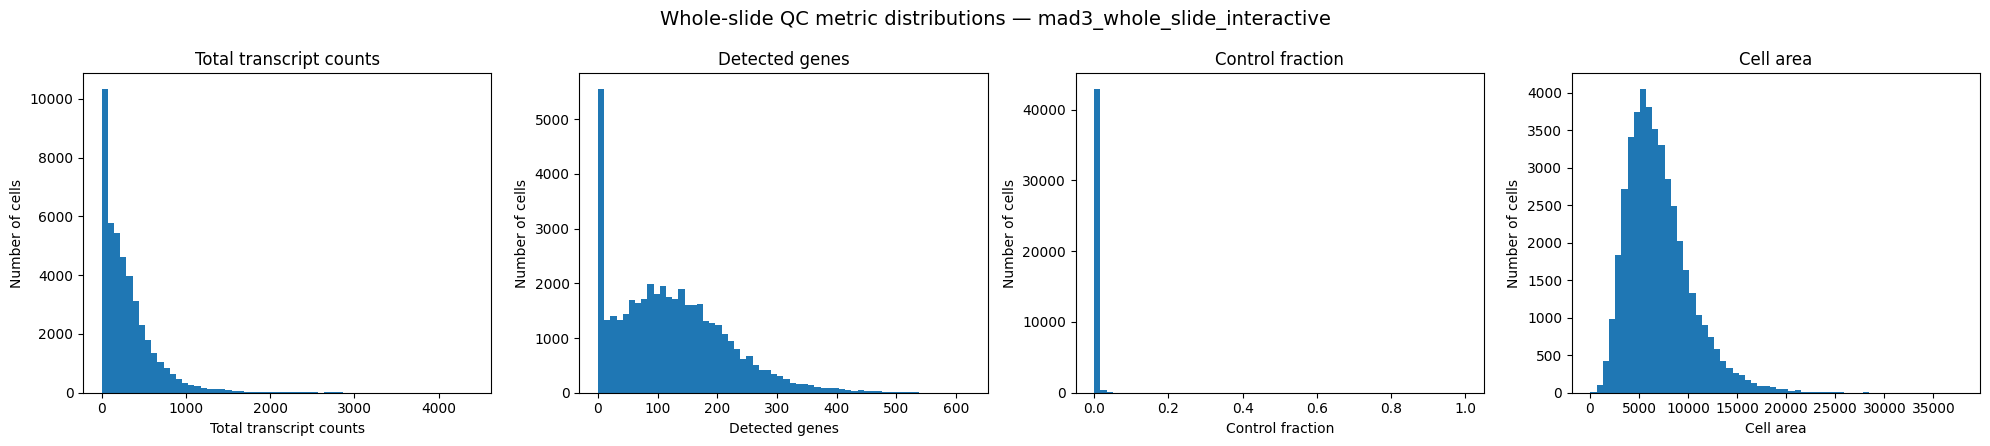

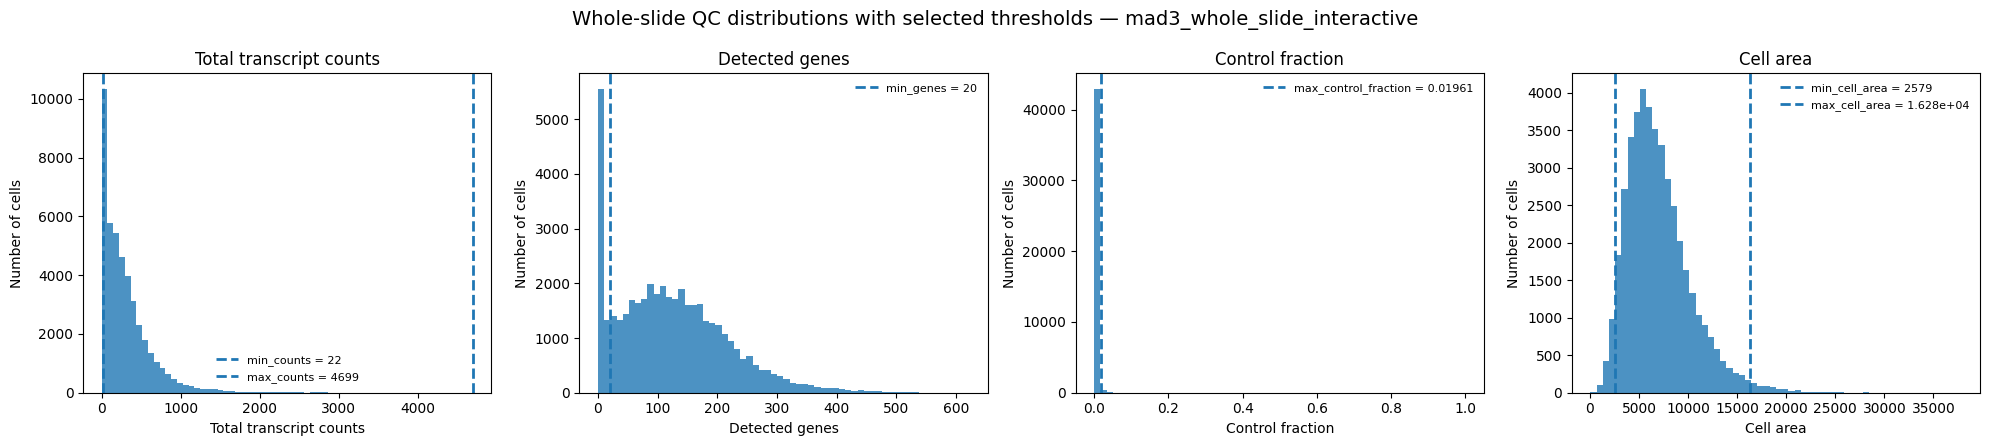

Planned raw figure      : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/whole_slide/qc_variants/mad3_whole_slide_interactive/figures/qc_metric_distributions_raw_mad3_whole_slide_interactive.png
Planned threshold figure: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/whole_slide/qc_variants/mad3_whole_slide_interactive/figures/qc_metric_distributions_with_thresholds_mad3_whole_slide_interactive.png


In [62]:
# ============================================================
# Raw QC distributions + selected-threshold distributions
# ============================================================
HIST_BINS = 60
SAVE_QC_FIGURES = False

QC_METRICS = [c for c in [
    "total_counts", "n_genes_by_counts", "control_fraction", "qc_cell_area"
] if c in a.obs.columns]

THRESHOLD_MAP = {
    "total_counts": {"lower": "min_counts", "upper": "max_counts"},
    "n_genes_by_counts": {"lower": "min_genes", "upper": "max_genes"},
    "control_fraction": {"lower": None, "upper": "max_control_fraction"},
    "qc_cell_area": {"lower": "min_cell_area", "upper": "max_cell_area"},
}
METRIC_LABELS = {
    "total_counts": "Total transcript counts",
    "n_genes_by_counts": "Detected genes",
    "control_fraction": "Control fraction",
    "qc_cell_area": "Cell area",
}

QC_OUTPUT_DIR = RESULTS_DIR / "whole_slide" / "qc_variants" / QC_TAG
QC_FIGURE_DIR = QC_OUTPUT_DIR / "figures"
RAW_DISTRIBUTION_FILE = QC_FIGURE_DIR / f"qc_metric_distributions_raw_{QC_TAG}.png"
THRESHOLD_DISTRIBUTION_FILE = QC_FIGURE_DIR / f"qc_metric_distributions_with_thresholds_{QC_TAG}.png"

def _numeric(metric):
    return pd.to_numeric(a.obs[metric], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()

def _thr(name):
    if name is None:
        return None
    v = QC_THRESHOLDS.get(name)
    if v is None:
        return None
    try:
        v = float(v)
    except (TypeError, ValueError):
        return None
    return v if np.isfinite(v) else None

# Raw distributions
fig_raw, axes = plt.subplots(1, len(QC_METRICS), figsize=(5*len(QC_METRICS), 4.5))
axes = np.atleast_1d(axes)
for ax, metric in zip(axes, QC_METRICS):
    ax.hist(_numeric(metric), bins=HIST_BINS)
    ax.set_title(METRIC_LABELS.get(metric, metric))
    ax.set_xlabel(METRIC_LABELS.get(metric, metric)); ax.set_ylabel("Number of cells")
fig_raw.suptitle(f"Whole-slide QC metric distributions — {QC_TAG}", fontsize=14)
fig_raw.tight_layout()
if SAVE_QC_FIGURES:
    QC_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig_raw.savefig(RAW_DISTRIBUTION_FILE, dpi=300, bbox_inches="tight")
plt.show()

# Same distributions with the exact thresholds used downstream
fig_thr, axes = plt.subplots(1, len(QC_METRICS), figsize=(5*len(QC_METRICS), 4.5))
axes = np.atleast_1d(axes)
for ax, metric in zip(axes, QC_METRICS):
    ax.hist(_numeric(metric), bins=HIST_BINS, alpha=0.8)
    info = THRESHOLD_MAP.get(metric, {})
    for side in ["lower", "upper"]:
        name = info.get(side); value = _thr(name)
        if value is not None:
            ax.axvline(value, linestyle="--", linewidth=2, label=f"{name} = {value:.4g}")
    ax.set_title(METRIC_LABELS.get(metric, metric))
    ax.set_xlabel(METRIC_LABELS.get(metric, metric)); ax.set_ylabel("Number of cells")
    if ax.get_legend_handles_labels()[0]: ax.legend(frameon=False, fontsize=8)
fig_thr.suptitle(f"Whole-slide QC distributions with selected thresholds — {QC_TAG}", fontsize=14)
fig_thr.tight_layout()
if SAVE_QC_FIGURES:
    QC_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig_thr.savefig(THRESHOLD_DISTRIBUTION_FILE, dpi=300, bbox_inches="tight")
plt.show()

print("Planned raw figure      :", RAW_DISTRIBUTION_FILE)
print("Planned threshold figure:", THRESHOLD_DISTRIBUTION_FILE)


In [63]:
# ============================================================
# Retention by FOV — important for whole-slide spatial QC
# ============================================================
retention_by_fov = (
    pd.DataFrame({"fov": a.obs["fov"].astype(str), "qc_pass": qc_keep.to_numpy()})
    .groupby("fov", observed=True)["qc_pass"]
    .agg(n_cells="size", n_pass="sum", retention="mean")
    .sort_index()
)
retention_by_fov["n_fail"] = retention_by_fov["n_cells"] - retention_by_fov["n_pass"]
display(retention_by_fov)


,n_cells,n_pass,retention,n_fail
fov,,,,
1,1083,1029,0.950139,54
10,1360,1289,0.947794,71
11,1020,977,0.957843,43
12,954,902,0.945493,52
13,1756,1639,0.933371,117
14,1327,1226,0.923888,101
15,642,478,0.744548,164
16,1037,925,0.891996,112
17,1369,528,0.385683,841


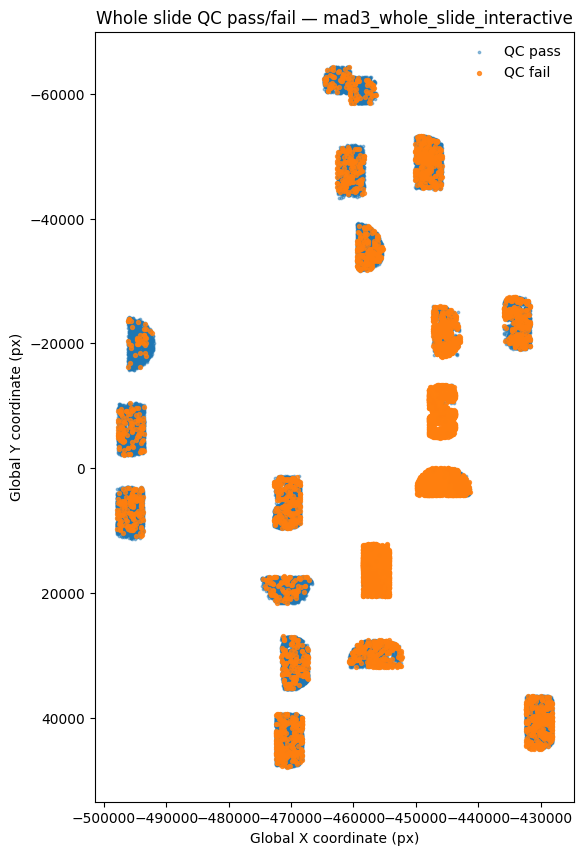

In [64]:
# Spatial QC pass/fail across the whole slide.
xy = np.asarray(a.obsm["spatial"])
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(xy[qc_keep.to_numpy(),0], xy[qc_keep.to_numpy(),1], s=3, alpha=.45, label="QC pass")
ax.scatter(xy[~qc_keep.to_numpy(),0], xy[~qc_keep.to_numpy(),1], s=8, alpha=.8, label="QC fail")
ax.set_aspect("equal"); ax.invert_yaxis(); ax.set_xlabel("Global X coordinate (px)"); ax.set_ylabel("Global Y coordinate (px)")
ax.set_title(f"Whole slide QC pass/fail — {QC_TAG}"); ax.legend(frameon=False)
plt.show()


In [65]:
# ============================================================
# Optionally save whole-slide QC diagnostics (not a filtered production object)
# ============================================================
SAVE_QC_DIAGNOSTICS = False
QC_THRESHOLDS_FILE = QC_OUTPUT_DIR / f"qc_thresholds_{QC_TAG}.json"
QC_RETENTION_FILE = QC_OUTPUT_DIR / f"retention_by_fov_{QC_TAG}.csv"
QC_SWEEP_FILE = QC_OUTPUT_DIR / f"qc_threshold_sweep_{QC_TAG}.csv"

print("QC output directory:", QC_OUTPUT_DIR)
print("SAVE_QC_DIAGNOSTICS:", SAVE_QC_DIAGNOSTICS)

if SAVE_QC_DIAGNOSTICS:
    QC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    QC_THRESHOLDS_FILE.write_text(json.dumps(QC_THRESHOLDS, indent=2))
    retention_by_fov.to_csv(QC_RETENTION_FILE)
    if qc_sweep is not None:
        qc_sweep.to_csv(QC_SWEEP_FILE, index=False)
    print("Saved thresholds:", QC_THRESHOLDS_FILE)
    print("Saved retention :", QC_RETENTION_FILE)


QC output directory: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/whole_slide/qc_variants/mad3_whole_slide_interactive
SAVE_QC_DIAGNOSTICS: False


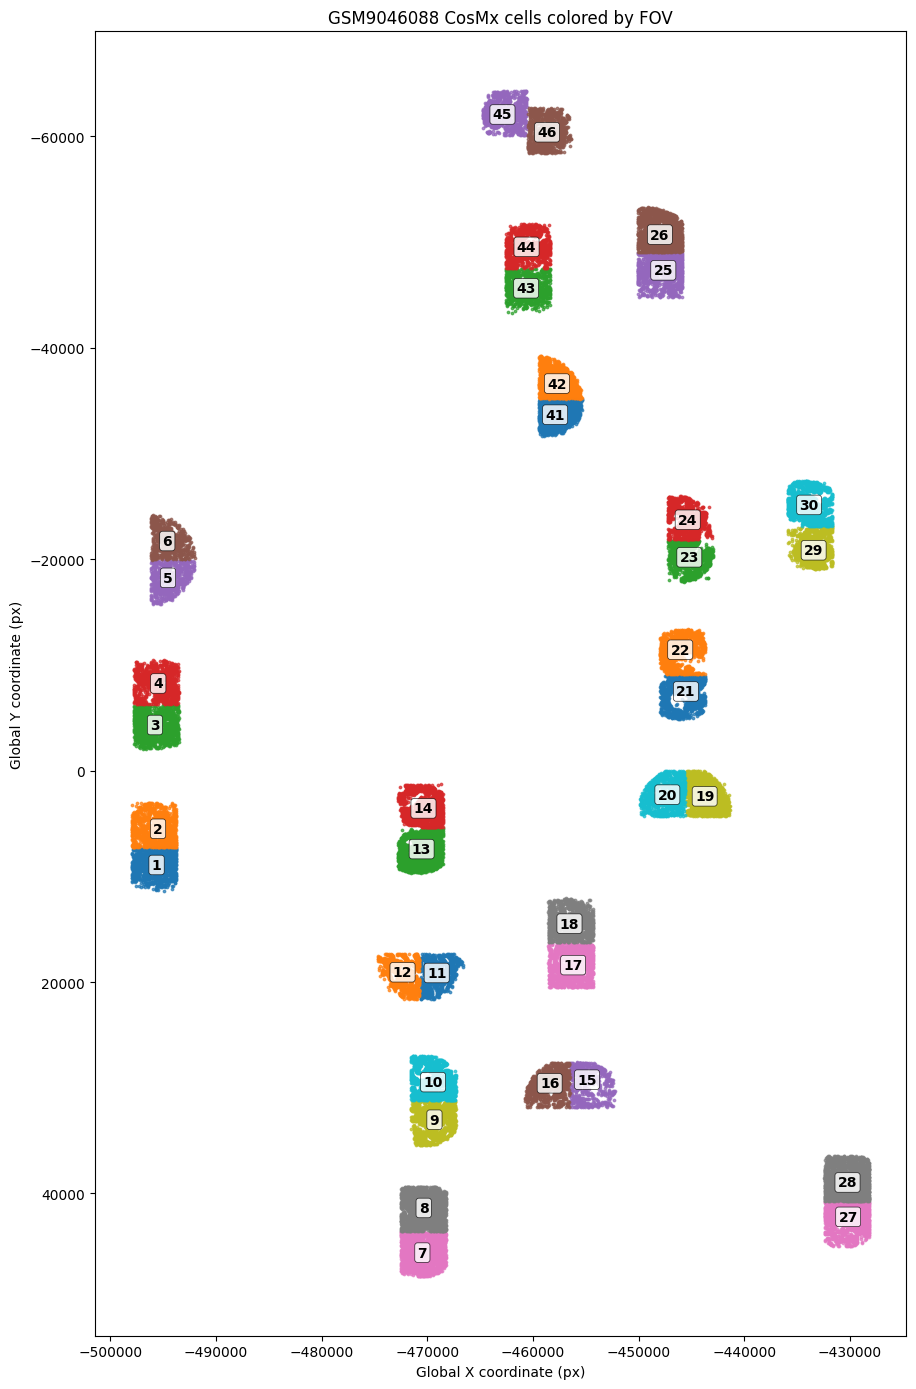

In [67]:
# Spatial layout colored by FOV + direct FOV labels.
# Presentation: clean direct labels; orientation: image/pixel convention (Y increases downward).
xy = np.asarray(a.obsm["spatial"])

fig, ax = plt.subplots(figsize=(10, 14))

for fov, idx in a.obs.groupby("fov", observed=True).groups.items():
    pos = a.obs_names.get_indexer(idx)
    x = xy[pos, 0]
    y = xy[pos, 1]

    ax.scatter(x, y, s=3, alpha=0.70)

    # Median is robust to irregular FOV shapes/outlying cells.
    ax.text(
        np.median(x), np.median(y), str(fov),
        fontsize=10, fontweight="bold", ha="center", va="center",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.20", facecolor="white",
            edgecolor="black", alpha=0.82, linewidth=0.5,
        ),
        zorder=10,
    )

ax.set_aspect("equal")
# Standard for all physical spatial plots in this project:
# keep raw coordinates unchanged, invert only the DISPLAY y-axis.
ax.invert_yaxis()
ax.set_xlabel("Global X coordinate (px)")
ax.set_ylabel("Global Y coordinate (px)")
ax.set_title("GSM9046088 CosMx cells colored by FOV")

# FOV numbers are already written directly on the tissue blocks,
# so a 46-entry legend is intentionally omitted.
plt.tight_layout()
plt.show()


## Optional whole-slide expression clustering
Adjust `MIN_COUNTS`, `MIN_GENES`, `N_PCS`, `N_NEIGHBORS`, and `RESOLUTION`, then rerun only this section.

normalizing counts per cell
    finished (0:00:00)


/home/jqu/.conda/envs/spatialdata/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


computing PCA
    with n_comps=30
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:02)
computing UMAP
    finished (0:00:24)
running Leiden clustering
    finished (0:00:23)
Clustering input: 34,797 QC-passing cells × 1,000 biological features


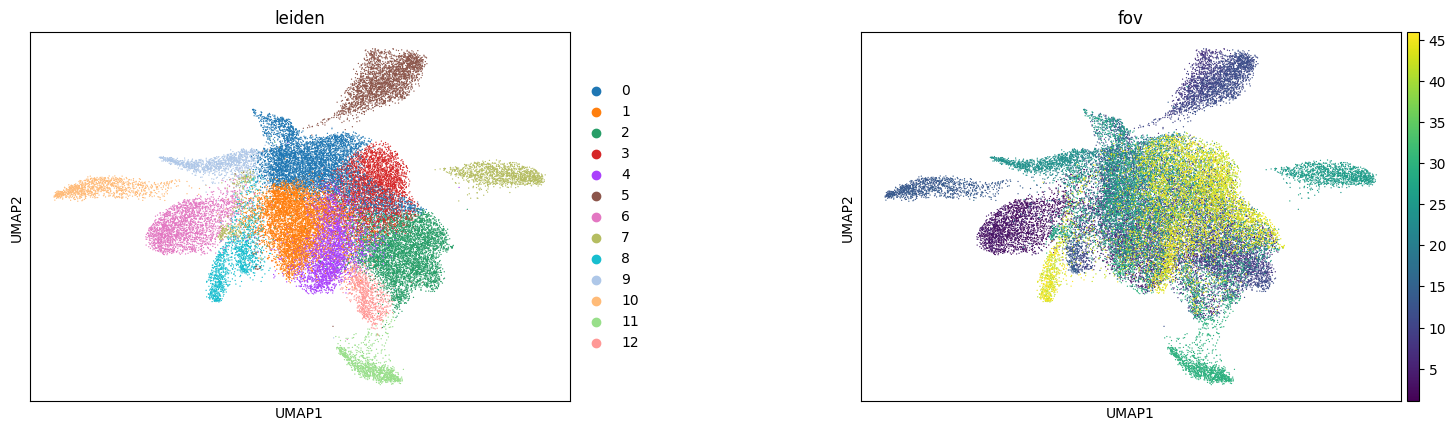

In [68]:
# ============================================================
# Optional whole-slide expression clustering
# IMPORTANT: uses the SAME qc_keep derived from QC_THRESHOLDS above.
# ============================================================
N_PCS = 30
N_NEIGHBORS = 15
RESOLUTION = 0.5
SEED = 42

biological = ~control_mask(a.var_names)
b = a[qc_keep.to_numpy(), biological].copy()
sc.pp.filter_genes(b, min_cells=1)
b.layers["counts"] = b.X.copy()

sc.pp.normalize_total(b, target_sum=1e4)
sc.pp.log1p(b)
b.raw = b.copy()
sc.pp.scale(b, max_value=10)

npcs = min(N_PCS, b.n_obs - 1, b.n_vars - 1)
sc.tl.pca(b, n_comps=npcs, svd_solver="arpack", random_state=SEED)
sc.pp.neighbors(b, n_neighbors=N_NEIGHBORS, n_pcs=npcs, random_state=SEED)
sc.tl.umap(b, random_state=SEED)
sc.tl.leiden(b, resolution=RESOLUTION, key_added="leiden", random_state=SEED)

print(f"Clustering input: {b.n_obs:,} QC-passing cells × {b.n_vars:,} biological features")
sc.pl.umap(b, color=["leiden", "fov"], frameon=True, wspace=.4)


fov,1,2,3,4,5,6,7,8,9,10,...,27,28,29,30,41,42,43,44,45,46
leiden,,,,,,,,,,,,,,,,,,,,,
0,0.010201,0.012967,0.006224,0.006051,0.012621,0.010719,0.034059,0.044606,0.021438,0.016252,...,0.076245,0.070194,0.008299,0.007780,0.025761,0.019191,0.043741,0.052386,0.023513,0.031985
1,0.032548,0.028620,0.042649,0.031238,0.011785,0.010475,0.092967,0.104938,0.027310,0.013094,...,0.079686,0.103816,0.075945,0.021511,0.008605,0.018893,0.017022,0.023943,0.019828,0.013655
2,0.014744,0.019188,0.024440,0.009493,0.033731,0.027267,0.110281,0.108463,0.085841,0.078368,...,0.018784,0.041406,0.028075,0.043022,0.007675,0.016966,0.027267,0.038578,0.033125,0.009897
3,0.006325,0.021386,0.003614,0.004518,0.039157,0.031325,0.030120,0.027410,0.015361,0.015060,...,0.048193,0.053313,0.002410,0.000301,0.139759,0.143373,0.043675,0.034337,0.076506,0.110241
4,0.030107,0.036258,0.034963,0.031078,0.042409,0.043056,0.030431,0.040142,0.006798,0.009388,...,0.056329,0.032049,0.029459,0.023309,0.045646,0.053415,0.046617,0.048559,0.070249,0.067659
5,0.000381,0.000000,0.000000,0.000000,0.000381,0.000000,0.066692,0.070122,0.189405,0.239329,...,0.000381,0.000381,0.000381,0.000381,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,0.242550,0.222268,0.253311,0.204884,0.009106,0.047185,0.000000,0.000000,0.000000,0.000000,...,0.002897,0.003725,0.000828,0.001242,0.000000,0.000000,0.000414,0.000000,0.000000,0.000000
7,0.000000,0.000625,0.001249,0.000000,0.000625,0.000625,0.000000,0.001249,0.000000,0.000000,...,0.051843,0.103061,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.032491,0.017329,0.000722,0.000722,0.010830,0.006498,...,0.001444,0.002888,0.002888,0.002888,0.156679,0.115523,0.034657,0.038989,0.101805,0.107581


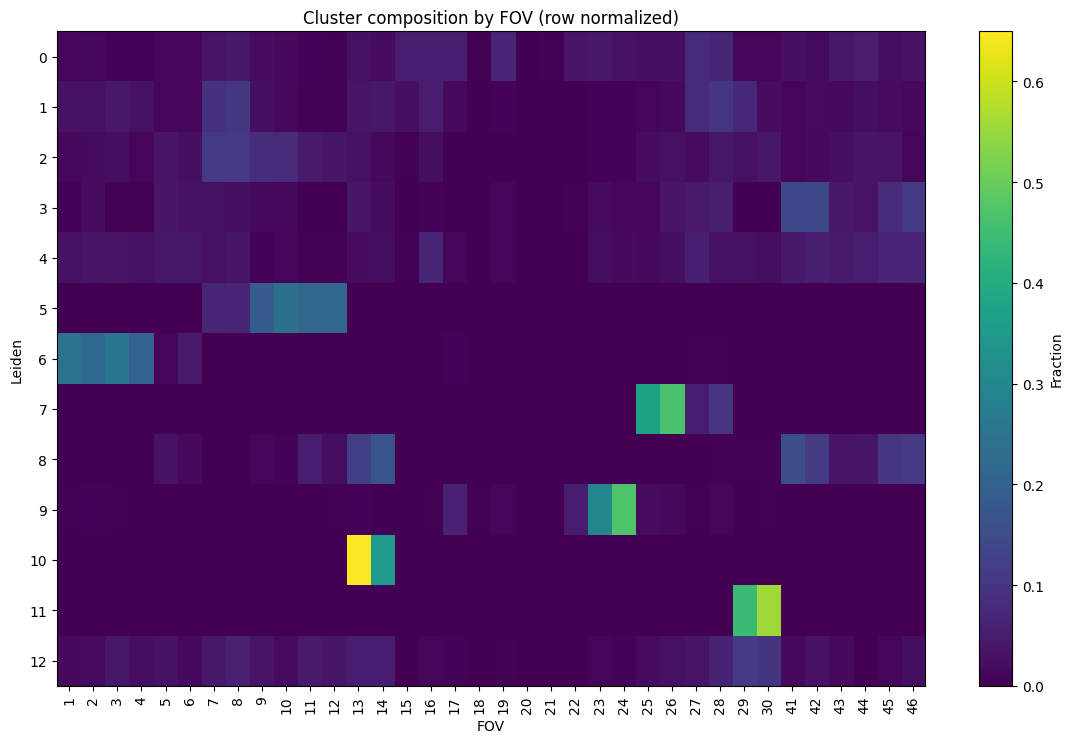

In [69]:
# Quantify cluster × FOV association.
cluster_fov = pd.crosstab(b.obs["leiden"], b.obs["fov"], normalize="index")
display(cluster_fov)
fig, ax = plt.subplots(figsize=(14, max(4, .5*cluster_fov.shape[0]+2)))
im=ax.imshow(cluster_fov, aspect="auto")
ax.set_yticks(range(cluster_fov.shape[0]), cluster_fov.index.astype(str))
ax.set_xticks(range(cluster_fov.shape[1]), cluster_fov.columns.astype(str), rotation=90)
ax.set_xlabel("FOV"); ax.set_ylabel("Leiden"); ax.set_title("Cluster composition by FOV (row normalized)")
fig.colorbar(im, ax=ax, label="Fraction"); plt.show()